In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
df = pd.read_csv("Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.Species.unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [11]:
name = {
    'Iris-setosa':0,
    'Iris-versicolor':1,
    "Iris-virginica":2
}

df.Species.replace(name,inplace=True)

C:\Users\Sugeshan\AppData\Local\Temp\ipykernel_10132\3444875601.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Species.replace(name,inplace=True)
C:\Users\Sugeshan\AppData\Local\Temp\ipykernel_10132\3444875601.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Species.replace(name,inplac

In [12]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [14]:
from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler()
scalar.fit_transform(df)

df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

x = df.drop('Species', axis=1)
y= df.Species

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.2, random_state=42)



In [16]:
for i in range(5,10):
    model = KNeighborsClassifier(n_neighbors=i).fit(x_train,y_train)

    y_pred = model.predict(x_test)

    print(f"Model accuracy for k = {i} is {accuracy_score(y_test,y_pred)}")

Model accuracy for k = 5 is 0.9916666666666667
Model accuracy for k = 6 is 0.975
Model accuracy for k = 7 is 0.9833333333333333
Model accuracy for k = 8 is 0.975
Model accuracy for k = 9 is 0.975


[[42  1  0]
 [ 0 39  0]
 [ 0  2 36]]


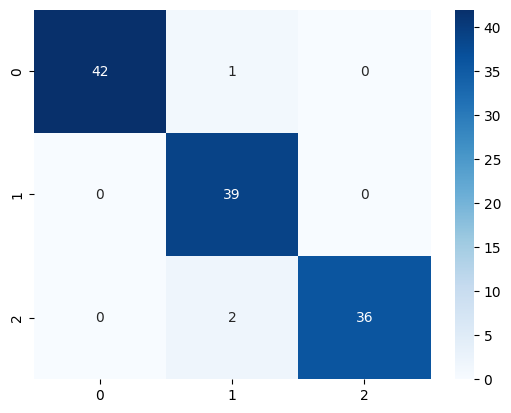

In [ ]:
import seaborn as sns
conf = confusion_matrix(y_test,y_pred)

sns.heatmap(conf, annot=True, cmap = 'Blues')
plt.show()